<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 6

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import copy
import random
import time
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from collections import defaultdict
from IPython.display import display
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
import torch.nn.functional as F
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [3]:
random_state = 333
# Reproducibility
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)
np.random.seed(random_state)
random.seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_state)
    torch.backends.cudnn.benchmark = True

Using device: cuda


## Table of Contents

* [Problem 6.1: Transfer Learning](#problem-61-transfer-learning)
* [Problem 6.2: Few-Shot Learning](#problem-62-few-shot-learning)

## Problem 6.1: Transfer Learning

### Objective
Fine-tune pre-trained models

### Tasks
- Use ResNet50 pre-trained on ImageNet.
- Fine-tune on a small custom image dataset (e.g., Cats vs. Dogs with 500 samples per class).
- Experiment with freezing different numbers of layers.
- Compare with training from scratch.

In this exercise we use transfer learning for a small cats vs dogs classifier. The main idea is simple: instead of training a deep model from zero, we start from ResNet50 trained on ImageNet and adapt it to our two classes. ResNet50 has about 25.5 million parameters and was trained on around 1.2 million images from 1000 classes. Because of that, the early and middle layers already know useful visual features like edges, textures, shapes, and object parts.

The basic structure is:

`input image -> ... -> layer1 -> layer2 -> layer3 -> layer4 -> fc`

For our task we replace the original `fc` layer with a new layer for 2 classes: cats and dogs.

The cats vs dogs dataset is already prepared in a simple folder structure. We only check how many images are in every split. Original Kaggle source: `curl -L -o ./dogs-cats-images.zip https://www.kaggle.com/api/v1/datasets/download/chetankv/dogs-cats-images`.

In [4]:
data_root = Path('./../datasets/dogs-cats-images')
classes = ['cats', 'dogs']
splits = ['train', 'validation', 'test']

rows = []
for split in splits:
    for class_name in classes:
        folder = data_root / split / class_name
        rows.append({
            'split': split,
            'class': class_name,
            'images': len(list(folder.glob('*.jpg'))),
        })

counts_df = pd.DataFrame(rows)
display(counts_df)

,split,class,images
0,train,cats,500
1,train,dogs,500
2,validation,cats,250
3,validation,dogs,250
4,test,cats,250
5,test,dogs,250


now lets preview a few images from each split

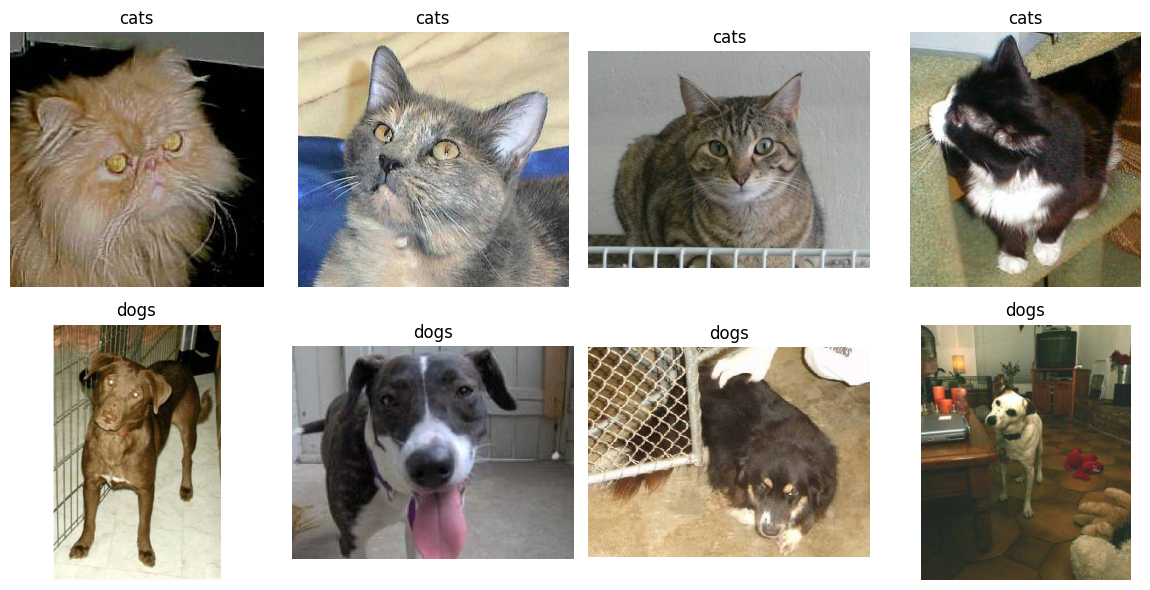

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row_idx, class_name in enumerate(classes):
    image_paths = sorted((data_root / 'train' / class_name).glob('*.jpg'))[:4]
    for col_idx, image_path in enumerate(image_paths):
        image = Image.open(image_path).convert('RGB')
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(class_name)
        axes[row_idx, col_idx].axis('off')
plt.tight_layout()
plt.show()

ResNet50 expects images normalized like ImageNet images. We also resize images to a fixed size.

For training we add simple augmentation. This means that the model does not always see exactly the same picture. Sometimes it sees a different crop or mirrored version, but the label is still the same.

In [6]:
image_size = 160 if device.type == 'cpu' else 224
batch_size = 16 if device.type == 'cpu' else 32
num_workers = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

image_datasets = {
    'train': datasets.ImageFolder(data_root / 'train', transform=train_transform),
    'validation': datasets.ImageFolder(data_root / 'validation', transform=eval_transform),
    'test': datasets.ImageFolder(data_root / 'test', transform=eval_transform),
}

generator = torch.Generator()
generator.manual_seed(random_state)

dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        generator=generator,
    ),
    'validation': DataLoader(
        image_datasets['validation'],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    ),
    'test': DataLoader(
        image_datasets['test'],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    ),
}

class_names = image_datasets['train'].classes
print(f'Classes: {class_names}')
print(f'Image size: {image_size}x{image_size}')
print(f'Batch size: {batch_size}')

images, labels = next(iter(dataloaders['train']))
print(f'One batch shape: {images.shape}')
print(f'Example labels: {labels[:8].tolist()}')

Classes: ['cats', 'dogs']
Image size: 224x224
Batch size: 32
One batch shape: torch.Size([32, 3, 224, 224])
Example labels: [1, 1, 1, 1, 0, 1, 0, 0]


Below we show a small example of this augmentation on one image. The animal is still the same, but the crop and orientation may change a bit.

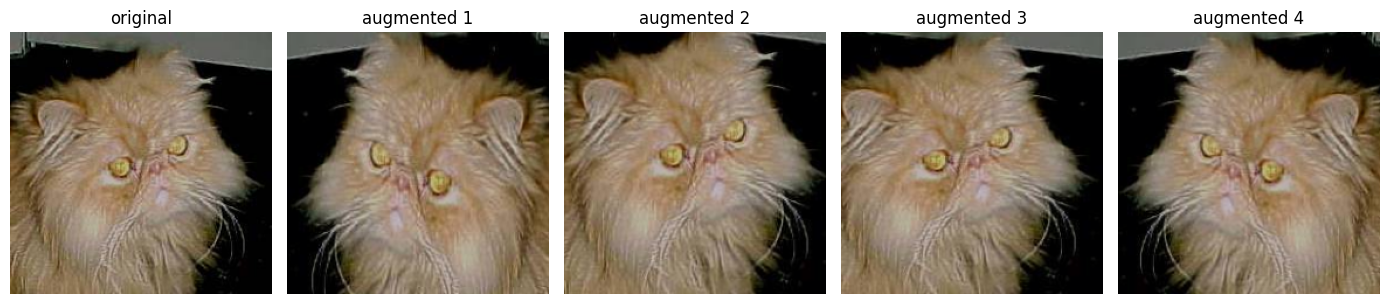

In [7]:
example_image_path = sorted((data_root / 'train' / 'cats').glob('*.jpg'))[0]
example_image = Image.open(example_image_path).convert('RGB')

fig, axes = plt.subplots(1, 5, figsize=(14, 4))
axes[0].imshow(example_image.resize((image_size, image_size)))
axes[0].set_title('original')
axes[0].axis('off')

for idx in range(1, 5):
    augmented = train_transform(example_image)
    augmented = augmented.permute(1, 2, 0).numpy()
    augmented = augmented * np.array(imagenet_std) + np.array(imagenet_mean)
    augmented = np.clip(augmented, 0, 1)

    axes[idx].imshow(augmented)
    axes[idx].set_title(f'augmented {idx}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

The augmentation example shows that one training image can appear in a few slightly different versions. Some crops are tighter and some images are flipped horizontally. It is still the same class, but model sees more visual variety during training.

We compare several fine-tuning strategies. In every pretrained case the original ImageNet head is replaced with a new `Linear(2048, 2)` layer. The difference between variants is how many ResNet blocks are trainable.

In [8]:
weights = ResNet50_Weights.DEFAULT
criterion = nn.CrossEntropyLoss()

def count_trainable_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return total, trainable

def build_resnet50_model(config):
    if config['pretrained']:
        model = models.resnet50(weights=weights)
        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, 2)

        if config['unfreeze'] in ['layer4', 'layer3_layer4']:
            for param in model.layer4.parameters():
                param.requires_grad = True
        if config['unfreeze'] == 'layer3_layer4':
            for param in model.layer3.parameters():
                param.requires_grad = True
    else:
        model = models.resnet50(weights=None, num_classes=2)

    return model.to(device)

def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc, np.array(all_targets), np.array(all_preds)

def train_model(config):
    model = build_resnet50_model(config)
    total_params, trainable_params = count_trainable_parameters(model)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=config['lr'],
        weight_decay=1e-4,
    )

    history = []
    best_val_loss = np.inf
    best_state = None
    started = time.time()

    print(f"Training {config['name']} ({trainable_params:,} trainable params)")
    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, _, _ = run_epoch(model, dataloaders['train'], optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, dataloaders['validation'])

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"epoch {epoch}: "
            f"train loss={train_loss:.3f}, train acc={train_acc:.3f}, "
            f"val loss={val_loss:.3f}, val acc={val_acc:.3f}"
        )

    model.load_state_dict(best_state)
    test_loss, test_acc, y_true, y_pred = run_epoch(model, dataloaders['test'])
    test_f1 = f1_score(y_true, y_pred)
    elapsed = time.time() - started

    result = {
        'model': config['name'],
        'total_params': total_params,
        'trainable_params': trainable_params,
        'best_val_loss': min(row['val_loss'] for row in history),
        'best_val_acc': max(row['val_acc'] for row in history),
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'time_sec': elapsed,
    }

    return model, pd.DataFrame(history), result, y_true, y_pred

Before running all experiments, we check if a ResNet50 forward pass works correctly for our batch shape.

In [9]:
dry_model = models.resnet50(weights=None, num_classes=2).to(device)
dry_model.eval()
with torch.no_grad():
    dry_outputs = dry_model(images[:2].to(device))
print(f'Dry forward output shape: {dry_outputs.shape}')
del dry_model

Dry forward output shape: torch.Size([2, 2])


Now we run four experiments. On CPU we use fewer epochs to keep the notebook practical, but every case is still trained on the same 1000 training images.

In [10]:
if device.type == 'cpu':
    experiment_configs = [
        {'name': 'head_only', 'pretrained': True, 'unfreeze': 'fc', 'epochs': 2, 'lr': 1e-3},
        {'name': 'layer4_fc', 'pretrained': True, 'unfreeze': 'layer4', 'epochs': 1, 'lr': 1e-4},
        {'name': 'layer3_layer4_fc', 'pretrained': True, 'unfreeze': 'layer3_layer4', 'epochs': 1, 'lr': 5e-5},
        {'name': 'scratch', 'pretrained': False, 'unfreeze': 'all', 'epochs': 1, 'lr': 3e-4},
    ]
else:
    experiment_configs = [
        {'name': 'head_only', 'pretrained': True, 'unfreeze': 'fc', 'epochs': 3, 'lr': 1e-3},
        {'name': 'layer4_fc', 'pretrained': True, 'unfreeze': 'layer4', 'epochs': 3, 'lr': 1e-4},
        {'name': 'layer3_layer4_fc', 'pretrained': True, 'unfreeze': 'layer3_layer4', 'epochs': 3, 'lr': 5e-5},
        {'name': 'scratch', 'pretrained': False, 'unfreeze': 'all', 'epochs': 3, 'lr': 3e-4},
    ]

histories = {}
results = []
test_predictions = {}
best_model_state = None
best_model_config = None
best_test_acc = -1

for config in experiment_configs:
    model, history, result, y_true, y_pred = train_model(config)
    histories[config['name']] = history
    results.append(result)
    test_predictions[config['name']] = (y_true, y_pred)

    if result['test_acc'] > best_test_acc:
        best_test_acc = result['test_acc']
        best_model_config = config.copy()
        best_model_state = copy.deepcopy(model.cpu().state_dict())

    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_display = results_df.copy()
for col in ['best_val_loss', 'best_val_acc', 'test_loss', 'test_acc', 'test_f1']:
    results_display[col] = results_display[col].round(3)
results_display['time_min'] = (results_display['time_sec'] / 60).round(2)
results_display = results_display.drop(columns='time_sec')
display(results_display)

Training head_only (4,098 trainable params)
epoch 1: train loss=0.348, train acc=0.890, val loss=0.176, val acc=0.990
epoch 2: train loss=0.138, train acc=0.971, val loss=0.094, val acc=0.986
epoch 3: train loss=0.093, train acc=0.984, val loss=0.069, val acc=0.992
Training layer4_fc (14,968,834 trainable params)
epoch 1: train loss=0.328, train acc=0.920, val loss=0.035, val acc=0.996
epoch 2: train loss=0.058, train acc=0.985, val loss=0.021, val acc=0.998
epoch 3: train loss=0.041, train acc=0.994, val loss=0.029, val acc=0.996
Training layer3_layer4_fc (22,067,202 trainable params)
epoch 1: train loss=0.482, train acc=0.822, val loss=0.205, val acc=0.992
epoch 2: train loss=0.141, train acc=0.982, val loss=0.036, val acc=0.996
epoch 3: train loss=0.048, train acc=0.995, val loss=0.025, val acc=0.998
Training scratch (23,512,130 trainable params)
epoch 1: train loss=0.886, train acc=0.519, val loss=1.191, val acc=0.500
epoch 2: train loss=0.680, train acc=0.610, val loss=0.889, val 

,model,total_params,trainable_params,best_val_loss,best_val_acc,test_loss,test_acc,test_f1,time_min
0,head_only,23512130,4098,0.069,0.992,0.096,0.982,0.982,0.77
1,layer4_fc,23512130,14968834,0.021,0.998,0.044,0.990,0.990,0.77
2,layer3_layer4_fc,23512130,22067202,0.025,0.998,0.041,0.988,0.988,0.82
3,scratch,23512130,23512130,0.889,0.542,0.956,0.508,0.605,0.97


The table already shows a big difference between pretrained models and training from scratch. `head_only` trains only about 4k parameters and still reaches around `0.98` test accuracy. When we unfreeze `layer4`, test accuracy increases to about `0.99`, so the last ResNet block can adapt a bit better to cats and dogs. Unfreezing also `layer3` gives a very similar result, but it trains much more parameters.

The scratch model is much weaker. It trains all 23.5M parameters, but with only 1000 training images it stays close to random guessing.

now we plot training curves

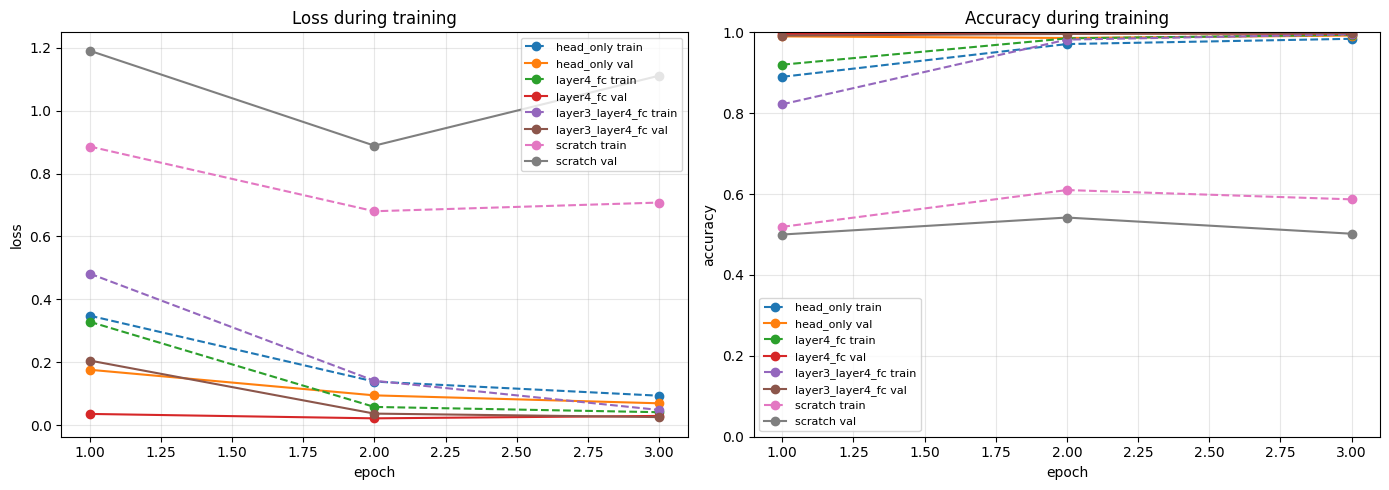

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, history in histories.items():
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', linestyle='--', label=f'{model_name} train')
    axes[0].plot(history['epoch'], history['val_loss'], marker='o', label=f'{model_name} val')
    axes[1].plot(history['epoch'], history['train_acc'], marker='o', linestyle='--', label=f'{model_name} train')
    axes[1].plot(history['epoch'], history['val_acc'], marker='o', label=f'{model_name} val')

axes[0].set_title('Loss during training')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(alpha=0.3)
axes[1].set_title('Accuracy during training')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

On the loss plot we can see that pretrained models quickly go down and keep very low validation loss. The scratch model behaves differently. Its validation accuracy stays around `0.5`, which means it did not really learn a stable cats vs dogs classifier in this short training.

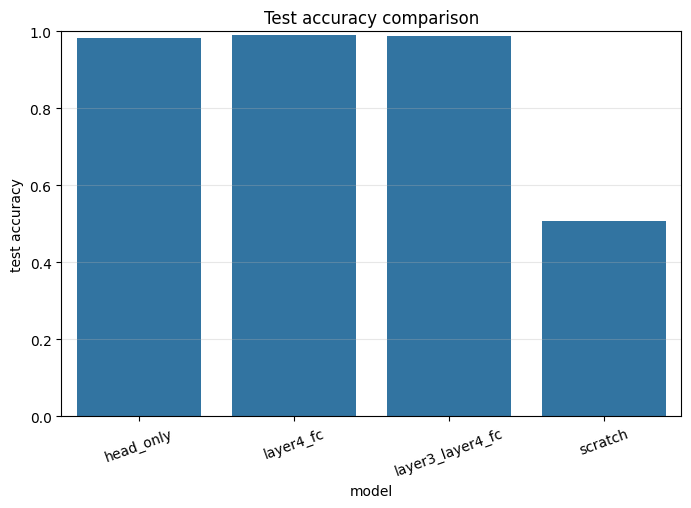

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='model', y='test_acc')
plt.title('Test accuracy comparison')
plt.xlabel('model')
plt.ylabel('test accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

The barplot makes the comparison very direct. All transfer learning models are near the top of the chart, while the scratch model is close to random classifier level.

and confusion matrices..

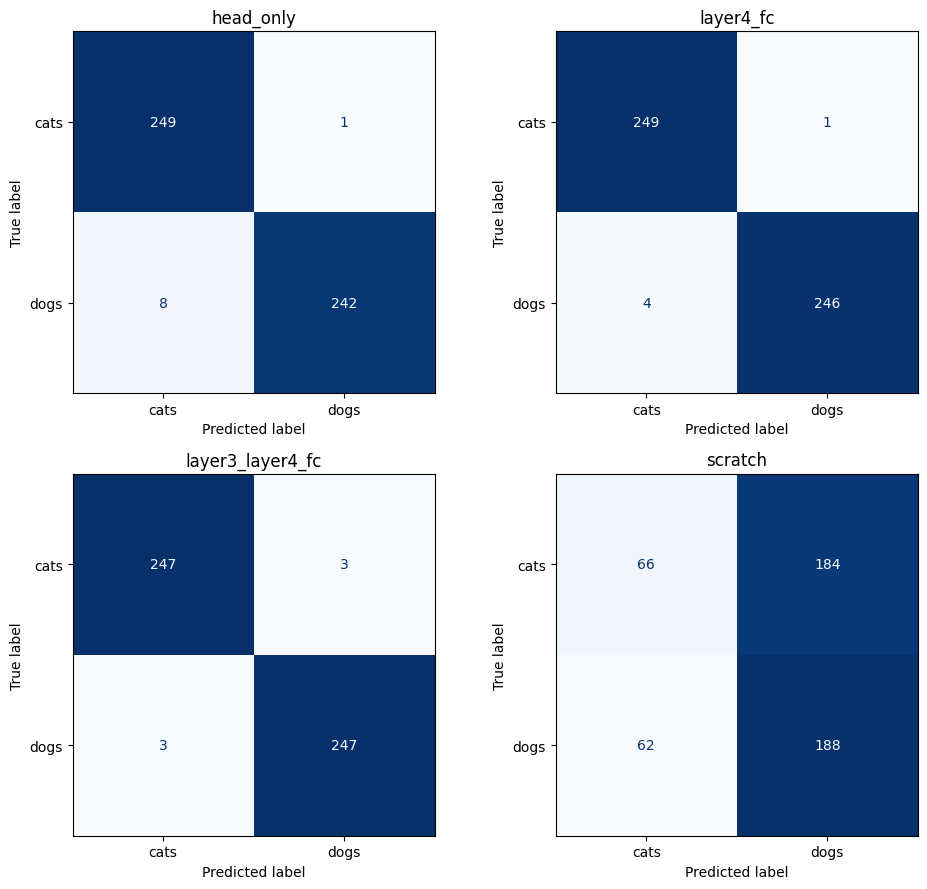

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (model_name, (y_true, y_pred)) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=class_names,
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

confusion matrices confirm the previous results. `head_only` makes only 9 mistakes on 500 test images. `layer4_fc` makes 5 mistakes, and `layer3_layer4_fc` makes 6 mistakes, so the pretrained models classify both classes very well. The scratch model almost always predicts `cats`. It classifies all cats correctly, but almost all dogs are also predicted as cats. This explains why its accuracy is around `0.5` and why its F1 score is very low.

finally we inspect a few predictions of the best model

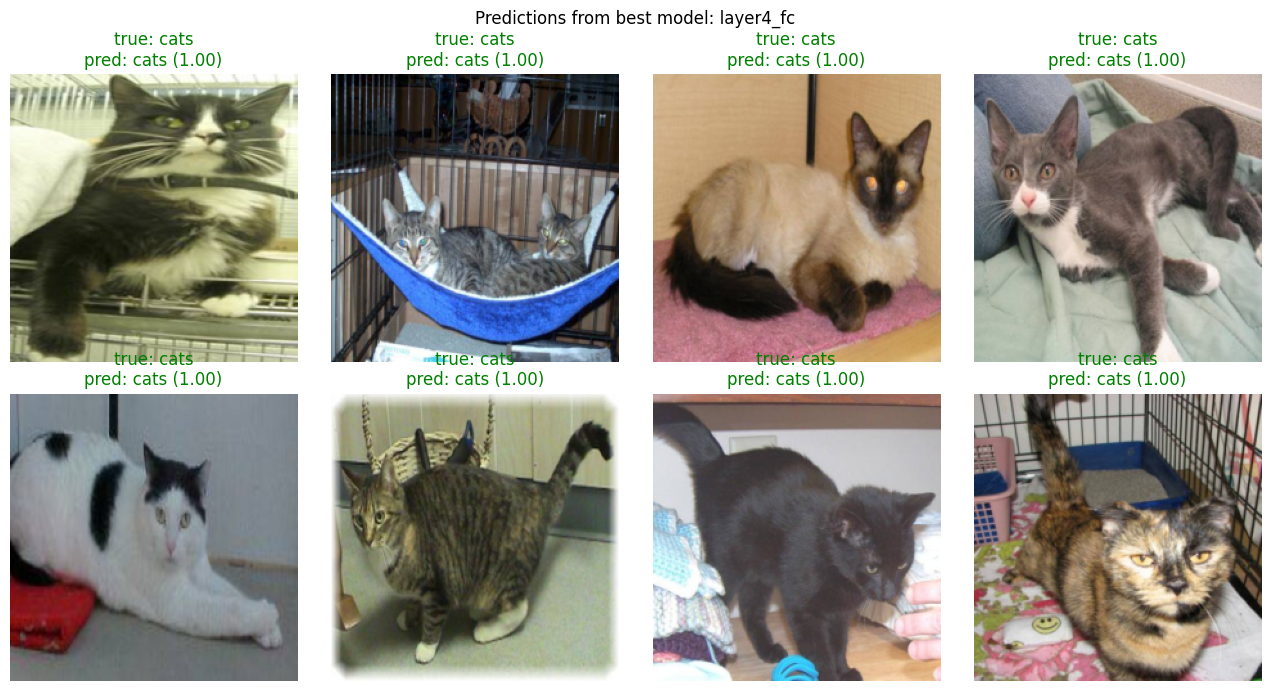

In [14]:
best_model = build_resnet50_model(best_model_config)
best_model.load_state_dict(best_model_state)
best_model.to(device)
best_model.eval()

def denormalize_image(tensor):
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(image, 0, 1)

test_images, test_labels = next(iter(dataloaders['test']))
with torch.no_grad():
    logits = best_model(test_images.to(device))
    probs = torch.softmax(logits, dim=1).cpu()
    preds = probs.argmax(dim=1)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for idx, ax in enumerate(axes.ravel()):
    image = denormalize_image(test_images[idx])
    true_label = class_names[test_labels[idx].item()]
    pred_label = class_names[preds[idx].item()]
    confidence = probs[idx, preds[idx]].item()
    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(image)
    ax.set_title(f'true: {true_label}\npred: {pred_label} ({confidence:.2f})', color=color)
    ax.axis('off')

plt.suptitle(f'Predictions from best model: {best_model_config["name"]}')
plt.tight_layout()
plt.show()

del best_model

### Last test on our own photos

at the end lets try test on our own images. We use photos of Kefir, my cat, and Trufla, my friends dog. These images were not used in training, so it is a nice small sanity check outside the prepared dataset

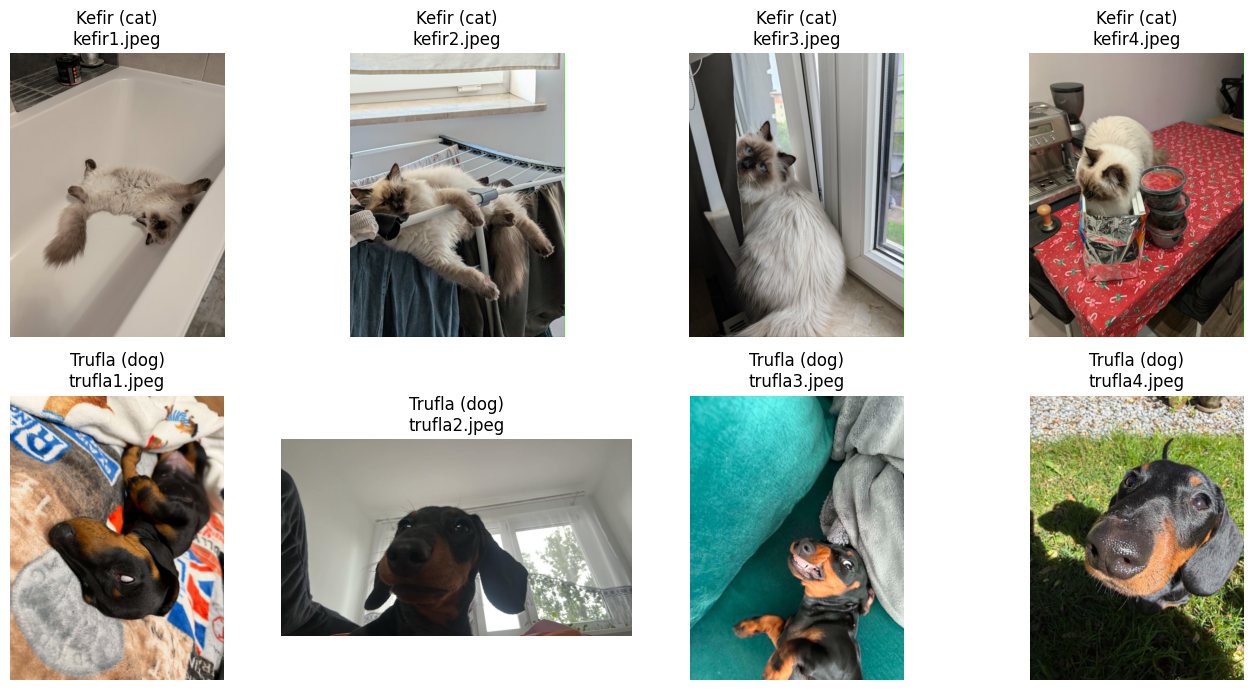

In [15]:
personal_root = Path('./../datasets/dogs-cats-images-personal')
personal_images = {
    'Kefir (cat)': sorted((personal_root / 'cat').glob('*')),
    'Trufla (dog)': sorted((personal_root / 'dog').glob('*')),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row_idx, (animal_name, image_paths) in enumerate(personal_images.items()):
    for col_idx, image_path in enumerate(image_paths[:4]):
        image = Image.open(image_path).convert('RGB')
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(f'{animal_name}\n{image_path.name}')
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

lets run it

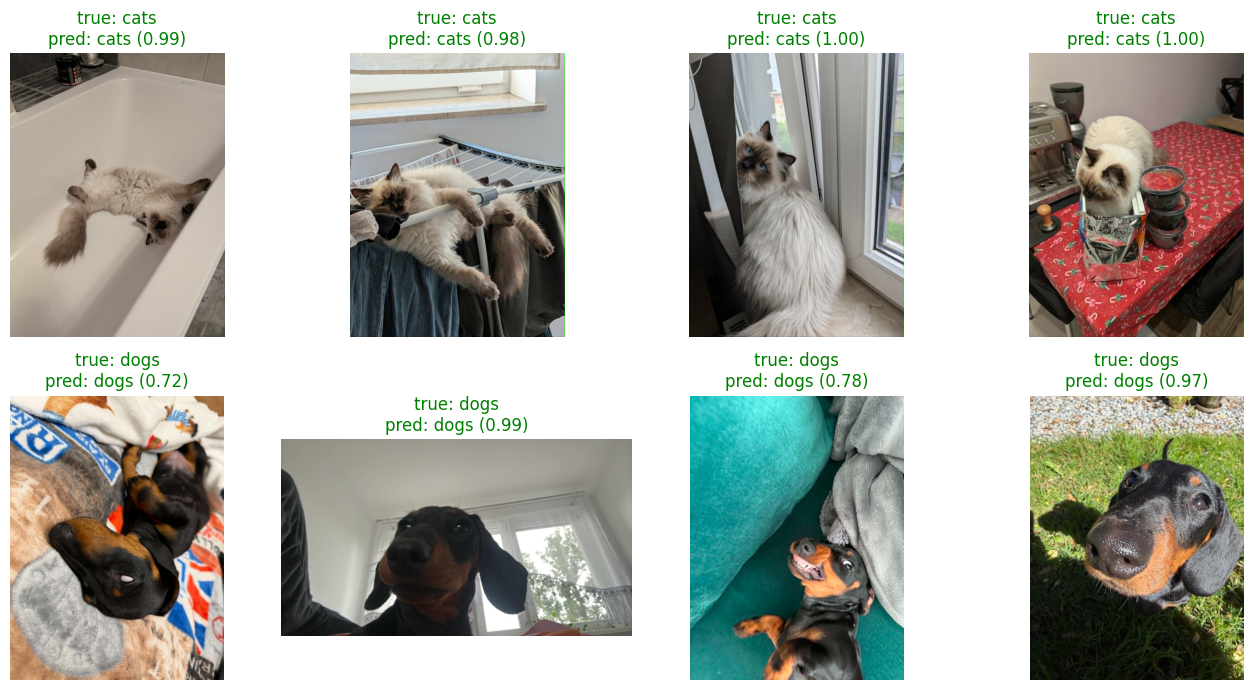

,image,true,predicted,confidence
0,kefir1.jpeg,cats,cats,0.995
1,kefir2.jpeg,cats,cats,0.984
2,kefir3.jpeg,cats,cats,0.998
3,kefir4.jpeg,cats,cats,0.995
4,trufla1.jpeg,dogs,dogs,0.720
5,trufla2.jpeg,dogs,dogs,0.988
6,trufla3.jpeg,dogs,dogs,0.778
7,trufla4.jpeg,dogs,dogs,0.972


In [16]:
personal_model = build_resnet50_model(best_model_config)
personal_model.load_state_dict(best_model_state)
personal_model.to(device)
personal_model.eval()

true_labels = {
    'Kefir (cat)': 'cats',
    'Trufla (dog)': 'dogs',
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
personal_results = []

for row_idx, (animal_name, image_paths) in enumerate(personal_images.items()):
    true_label = true_labels[animal_name]
    for col_idx, image_path in enumerate(image_paths[:4]):
        image = Image.open(image_path).convert('RGB')
        image_tensor = eval_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = personal_model(image_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        pred_label = class_names[pred_idx]
        confidence = probs[pred_idx]
        color = 'green' if pred_label == true_label else 'red'

        personal_results.append({
            'image': image_path.name,
            'true': true_label,
            'predicted': pred_label,
            'confidence': round(float(confidence), 3),
        })

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(
            f'true: {true_label}\npred: {pred_label} ({confidence:.2f})',
            color=color,
        )
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

display(pd.DataFrame(personal_results))
del personal_model

The personal test worked nicely. All 4 photos of Kefir were classified as `cats`, with very high confidence around `0.98-1.00`. Trufla was also classified correctly as `dogs` in all 4 photos, although two predictions had lower confidence, around `0.73` and `0.79`. this is not a formal evaluation, but it is a nice final check. The model did not only work on the prepared Kaggle split, but also on our own photos with different background, lighting and camera style.

### Conclusions

The results clearly show why transfer learning is useful here. Even the `head_only` model, where only 4098 parameters were trained, reached about `0.98` test accuracy. Fine-tuning later blocks improved the result a little bit. `layer4_fc` and `layer3_layer4_fc` both reached about `0.99` test accuracy. Their confusion matrices are also very clean: only around 5 mistakes on 500 test images. The difference between these two variants is small, so in practice `layer4_fc` is probably the best trade-off, because it trains fewer parameters than unfreezing both layer3 and layer4. Training ResNet50 from scratch worked much worse. It got only about `0.55` test accuracy and the confusion matrix shows a strong bias toward predicting `cats`.

Overall, the experiment confirms the main idea of transfer learning: with a small dataset, it is much better to start from a pretrained visual model and fine-tune only the classification head or the last blocks, instead of learning all visual features from zero. The personal photos at the end are not a benchmark, but they make a nice final sanity check. It shows how the trained model behaves on images outside the prepared Kaggle split.

## Problem 6.2: Few-Shot Learning

### Objective
Implement prototypical networks

### Tasks
- Use Omniglot or mini-ImageNet dataset.
- Implement 5-way 1-shot and 5-way 5-shot classification.
- Calculate episode-wise accuracy.
- Visualize embeddings using t-SNE.

We use `torchvision.datasets.Omniglot` with two splits:

- `background=True`: the training set, containing 964 character classes
- `background=False`: the test set, containing 659 character classes

Each class contains exactly 20 handwritten examples. Every image is resized to 28x28 pixels and rescaled to the [0, 1] range by `ToTensor()`.

In [17]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

train_dataset = datasets.Omniglot(
    root="./data", background=True, download=True, transform=transform
)
test_dataset = datasets.Omniglot(
    root="./data", background=False, download=True, transform=transform
)

print(f"Training classes: {len(train_dataset._characters)}")
print(f"Test classes: {len(test_dataset._characters)}")
print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

Training classes: 964
Test classes: 659
Training images: 19280
Test images: 13180


For sampling episodes efficiently, we build a dictionary for each split that maps a class number (key) to the list of dataset indices belonging to that class (value). This lets us quickly pick random support and query instances for any class.

In [18]:
def build_class_dict(dataset):
    class_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset._flat_character_images):
        class_to_indices[label].append(idx)
    return class_to_indices


train_class_dict = build_class_dict(train_dataset)
test_class_dict = build_class_dict(test_dataset)

print(f"Number of training classes: {len(train_class_dict)}")
print(f"Number of test classes: {len(test_class_dict)}")
print(f"Images in training class 0: {len(train_class_dict[0])}")

Number of training classes: 964
Number of test classes: 659
Images in training class 0: 20


Before going further, let's actually look at the data we are working with. Omniglot contains handwritten characters from many alphabets, where each class is a single character and each instance is one handwritten example of that character. Below we show a few random classes from the training set, with several handwritten instances of each.

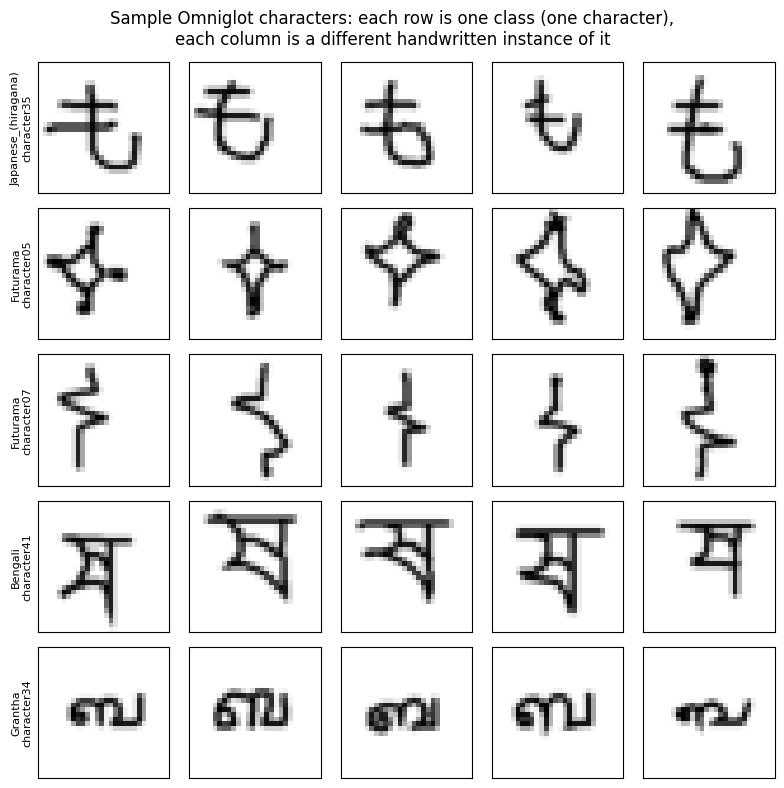

In [19]:
random.seed(random_state)
sample_classes = random.sample(list(train_class_dict.keys()), 5)

fig, axes = plt.subplots(len(sample_classes), 5, figsize=(8, 8))
for row, cls in enumerate(sample_classes):
    instance_indices = random.sample(train_class_dict[cls], 5)
    for col, idx in enumerate(instance_indices):
        img, _ = train_dataset[idx]
        axes[row, col].imshow(img.squeeze(), cmap="gray")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        if col == 0:
            # / on Linux/Mac
            # \ on Windows
            label = re.split(r"[\\/]", train_dataset._characters[cls])
            axes[row, col].set_ylabel("\n".join(label), fontsize=8)

plt.suptitle("Sample Omniglot characters: each row is one class (one character),\neach column is a different handwritten instance of it")
plt.tight_layout()
plt.show()

Each row above is one class, and the five images in that row are different handwriting samples of the same character. This is the source of the difficulty in few-shot learning: within a class there is real variation (stroke thickness, slant, exact shape), and across classes some characters can look fairly similar. The model has to learn an embedding where, despite this variation, instances of the same character end up closer to each other than to instances of other characters, using only a handful of labeled examples per class.

Now, we build the CNN encoder. It maps a 28x28 grayscale image to a 64-dimensional embedding vector. It consists of 4 convolutional blocks, where each block applies:

`Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d(2)`

Starting from a 28x28 input, four poolings of stride 2 reduce the spatial size to 1x1, so the final feature map already has a proper shape and can be flattened directly into a 64-dimensional vector.

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class CNNEncoder(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)


# shape check
encoder = CNNEncoder().to(device)
dummy = torch.randn(2, 1, 28, 28).to(device)
print(f"Output embedding shape: {encoder(dummy).shape}")

Output embedding shape: torch.Size([2, 64])


At this moment, we can work on a single few-shot classification task, which consists of:

- An `n_way` choice of classes, sampled randomly from the available classes of the given split
- For each chosen class, `n_shot` support instances and `n_query` query instances are sampled, again at random
- Query labels are remapped to the episode-local label space `0, ..., n_way - 1`

The function below returns the support images, query images, and query labels as tensors, ready to be passed through the encoder.

In [21]:
def sample_episode(dataset, class_dict, n_way, n_shot, n_query):
    classes = random.sample(list(class_dict.keys()), n_way)

    support_images = []
    query_images = []
    query_labels = []

    for episode_label, cls in enumerate(classes):
        indices = random.sample(class_dict[cls], n_shot + n_query)
        support_indices = indices[:n_shot]
        query_indices = indices[n_shot:]

        for idx in support_indices:
            img, _ = dataset[idx]
            support_images.append(img)

        for idx in query_indices:
            img, _ = dataset[idx]
            query_images.append(img)
            query_labels.append(episode_label)

    support_images = torch.stack(support_images)
    query_images = torch.stack(query_images)
    query_labels = torch.tensor(query_labels, dtype=torch.long)

    return support_images, query_images, query_labels


# quick check with 5-way 1-shot
support_images, query_images, query_labels = sample_episode(
    train_dataset, train_class_dict, n_way=5, n_shot=1, n_query=15
)
print(f"Support set shape: {support_images.shape}")
print(f"Query set shape: {query_images.shape}")
print(f"Query labels shape: {query_labels.shape}")

Support set shape: torch.Size([5, 1, 28, 28])
Query set shape: torch.Size([75, 1, 28, 28])
Query labels shape: torch.Size([75])


Now, we:

1. Pass all support and query images through the CNN encoder to get their embedding vectors
2. Compute a prototype for each class as the mean embedding vector of its support instances
3. Compute squared Euclidean distances between every query embedding and every prototype
4. Use the negative distances as logits for a cross-entropy loss
5. Predict the class of each query instance as the class with the nearest prototype, and compute accuracy

The idea behind this setup is that embeddings from the same class should end up close together in the embedding space, while embeddings from different classes should be far apart. Training repeatedly over many episodes is how the encoder learns to produce such embeddings.

In [22]:
def run_episode(encoder, dataset, class_dict, n_way, n_shot, n_query, device):
    support_images, query_images, query_labels = sample_episode(
        dataset, class_dict, n_way, n_shot, n_query
    )

    support_images = support_images.to(device)
    query_images = query_images.to(device)
    query_labels = query_labels.to(device)

    support_embeddings = encoder(support_images)
    query_embeddings = encoder(query_images)

    # prototype = mean embedding of support instances of each class
    prototypes = support_embeddings.view(n_way, n_shot, -1).mean(dim=1)

    # squared Euclidean distance between each query embedding and each prototype
    distances = torch.cdist(query_embeddings, prototypes) ** 2

    # negative distances act as logits
    logits = -distances
    loss = F.cross_entropy(logits, query_labels)

    predictions = logits.argmax(dim=1)
    accuracy = (predictions == query_labels).float().mean().item()

    return loss, accuracy


# check on an untrained encoder
encoder = CNNEncoder().to(device)
loss, acc = run_episode(encoder, train_dataset, train_class_dict, n_way=5, n_shot=1, n_query=15, device=device)
print(f"Initial loss: {loss.item():.4f}, accuracy: {acc:.4f}")

Initial loss: 2.0808, accuracy: 0.7067


We can now define a reusable training function. For a chosen `n_way`/`n_shot` configuration, it:

1. Creates a fresh CNN encoder and Adam optimizer
2. Runs a fixed number of training episodes, each time sampling support and query sets from the training set
3. For each episode, computes the loss, backpropagates, and updates the encoder weights
4. Records the episode-wise loss and accuracy for later plotting

We will run this for both the 5-way 1-shot and the 5-way 5-shot configurations.

In [23]:
def train_model(n_way, n_shot, n_query=15, num_episodes=500, lr=1e-3):
    encoder = CNNEncoder().to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

    losses = []
    accuracies = []

    for episode in range(1, num_episodes + 1):
        encoder.train()
        loss, acc = run_episode(
            encoder, train_dataset, train_class_dict, n_way, n_shot, n_query, device
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accuracies.append(acc)

        if episode % 100 == 0:
            recent_loss = np.mean(losses[-100:])
            recent_acc = np.mean(accuracies[-100:])
            print(f"Episode {episode}/{num_episodes} - loss: {recent_loss:.4f}, accuracy: {recent_acc:.4f}")

    return encoder, losses, accuracies


def moving_average(values, window=20):
    values = np.array(values)
    if len(values) < window:
        return values
    cumsum = np.cumsum(np.insert(values, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window


def plot_training_curves(losses, accuracies, title_suffix, window=20):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(losses, alpha=0.3, label="raw")
    axes[0].plot(range(window, len(losses) + 1), moving_average(losses, window), label=f"moving avg ({window})")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Training loss - {title_suffix}")
    axes[0].legend()

    axes[1].plot(accuracies, alpha=0.3, label="raw")
    axes[1].plot(range(window, len(accuracies) + 1), moving_average(accuracies, window), label=f"moving avg ({window})")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Training accuracy - {title_suffix}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

To evaluate a trained encoder, we run a number of episodes sampled from the test set. For each episode we compute the query set accuracy. We then report the average accuracy and its confidence interval.

In [24]:
def evaluate_model(encoder, n_way, n_shot, n_query=15, num_episodes=100):
    encoder.eval()
    accuracies = []

    with torch.no_grad():
        for _ in range(num_episodes):
            _, acc = run_episode(
                encoder, test_dataset, test_class_dict, n_way, n_shot, n_query, device
            )
            accuracies.append(acc)

    accuracies = np.array(accuracies)
    mean_acc = accuracies.mean()
    std_acc = accuracies.std()


    ci_lower = max(0.0, mean_acc - 2 * std_acc)
    ci_upper = min(1.0, mean_acc + 2 * std_acc)

    print(f"Average accuracy over {num_episodes} episodes: {mean_acc:.4f}")
    print(f"Mean +/- 2 std = {mean_acc:.4f} +/- {2 * std_acc:.4f}")
    print(f"95% confidence interval (clipped to [0, 1]) = [{ci_lower:.4f}, {ci_upper:.4f}]")

    return mean_acc, std_acc, accuracies

At the end, for a single test episode, we compute the embeddings of all query set instances and the prototypes of all classes, then illustrate both using t-SNE.

In [25]:
def visualize_episode_tsne(encoder, n_way, n_shot, n_query, title_suffix):
    encoder.eval()
    support_images, query_images, query_labels = sample_episode(
        test_dataset, test_class_dict, n_way, n_shot, n_query
    )

    support_images = support_images.to(device)
    query_images = query_images.to(device)

    with torch.no_grad():
        support_embeddings = encoder(support_images)
        query_embeddings = encoder(query_images)
        prototypes = support_embeddings.view(n_way, n_shot, -1).mean(dim=1)

    query_embeddings_np = query_embeddings.cpu().numpy()
    prototypes_np = prototypes.cpu().numpy()
    query_labels_np = query_labels.numpy()

    # combine query embeddings and prototypes for a joint t-SNE projection
    combined = np.concatenate([query_embeddings_np, prototypes_np], axis=0)
    perplexity = min(30, max(5, len(combined) // 4))
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, init="pca")
    projected = tsne.fit_transform(combined)

    n_query_total = query_embeddings_np.shape[0]
    query_2d = projected[:n_query_total]
    prototypes_2d = projected[n_query_total:]

    plt.figure(figsize=(7, 6))
    cmap = plt.get_cmap("tab10")

    for cls in range(n_way):
        mask = query_labels_np == cls
        plt.scatter(query_2d[mask, 0], query_2d[mask, 1], color=cmap(cls), alpha=0.6, label=f"class {cls} query")

    for cls in range(n_way):
        plt.scatter(prototypes_2d[cls, 0], prototypes_2d[cls, 1], color=cmap(cls), marker="*", s=300, edgecolors="black", linewidths=1.2, label=f"class {cls} prototype")

    plt.title(f"t-SNE of query embeddings and prototypes - {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

We now run the full pipeline for the 5-way 1-shot setting: 5 classes per episode, 1 support instance per class, 15 query instances per class.

Training

In [26]:
N_WAY = 5
N_SHOT_1 = 1
N_QUERY = 15
NUM_TRAIN_EPISODES = 500
NUM_TEST_EPISODES = 100

start = time.time()
encoder_1shot, losses_1shot, accuracies_1shot = train_model(
    n_way=N_WAY, n_shot=N_SHOT_1, n_query=N_QUERY, num_episodes=NUM_TRAIN_EPISODES
)
print(f"Training took {time.time() - start:.1f} seconds")

Episode 100/500 - loss: 0.8544, accuracy: 0.7871
Episode 200/500 - loss: 0.3190, accuracy: 0.8944
Episode 300/500 - loss: 0.2491, accuracy: 0.9105
Episode 400/500 - loss: 0.1816, accuracy: 0.9401
Episode 500/500 - loss: 0.2131, accuracy: 0.9276
Training took 30.8 seconds


Training curves

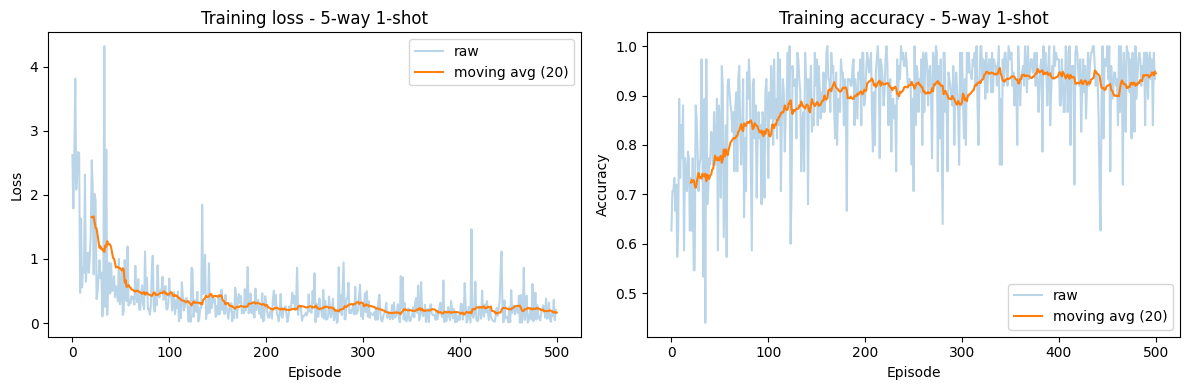

In [27]:
plot_training_curves(losses_1shot, accuracies_1shot, title_suffix="5-way 1-shot")

Although the curves are noisy, we see the decreasing trend in the training loss, and the increasing trend in the training accuracy. When we look at the moving average the drift is clearly visible and the curve is smoother. These plots show that the model is in fact learning on the training set.

Evaluation on the test set

In [28]:
mean_acc_1shot, std_acc_1shot, accs_1shot = evaluate_model(
    encoder_1shot, n_way=N_WAY, n_shot=N_SHOT_1, n_query=N_QUERY, num_episodes=NUM_TEST_EPISODES
)

Average accuracy over 100 episodes: 0.8876
Mean +/- 2 std = 0.8876 +/- 0.1532
95% confidence interval (clipped to [0, 1]) = [0.7344, 1.0000]


t-SNE visualization of query embeddings and prototypes

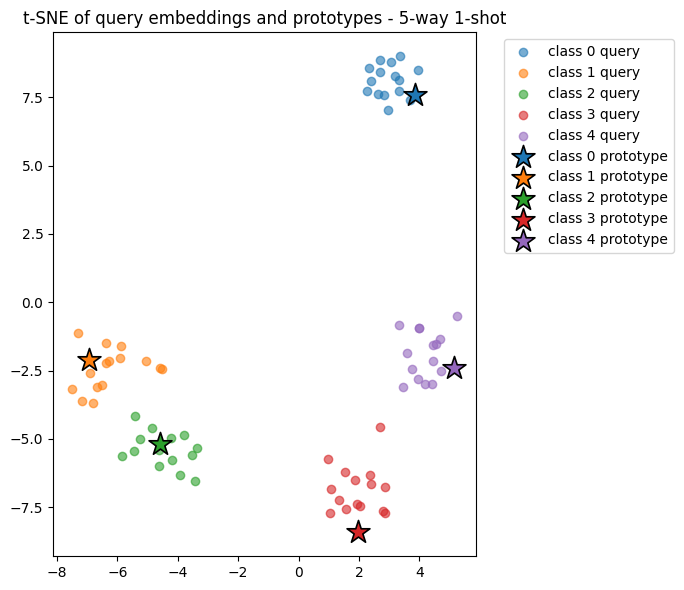

In [29]:
visualize_episode_tsne(encoder_1shot, n_way=N_WAY, n_shot=N_SHOT_1, n_query=N_QUERY, title_suffix="5-way 1-shot")

We can see that points within one class are in fact close to each other. The stars representing the prototypes are placed close to the corresponding queries.

Now, we repeat the same pipeline for the 5-way 5-shot setting: 5 classes per episode, 5 support instances per class, 15 query instances per class. With 20 images per class in Omniglot, this uses all available images per class within an episode.

A separate encoder is trained from scratch for this setting, since the prototype computation depends on `n_shot`.

Training

In [30]:
N_SHOT_5 = 5

start = time.time()
encoder_5shot, losses_5shot, accuracies_5shot = train_model(
    n_way=N_WAY, n_shot=N_SHOT_5, n_query=N_QUERY, num_episodes=NUM_TRAIN_EPISODES
)
print(f"Training took {time.time() - start:.1f} seconds")

Episode 100/500 - loss: 0.2526, accuracy: 0.9301
Episode 200/500 - loss: 0.0922, accuracy: 0.9713
Episode 300/500 - loss: 0.0735, accuracy: 0.9749
Episode 400/500 - loss: 0.0642, accuracy: 0.9787
Episode 500/500 - loss: 0.0536, accuracy: 0.9812
Training took 36.4 seconds


Training curves

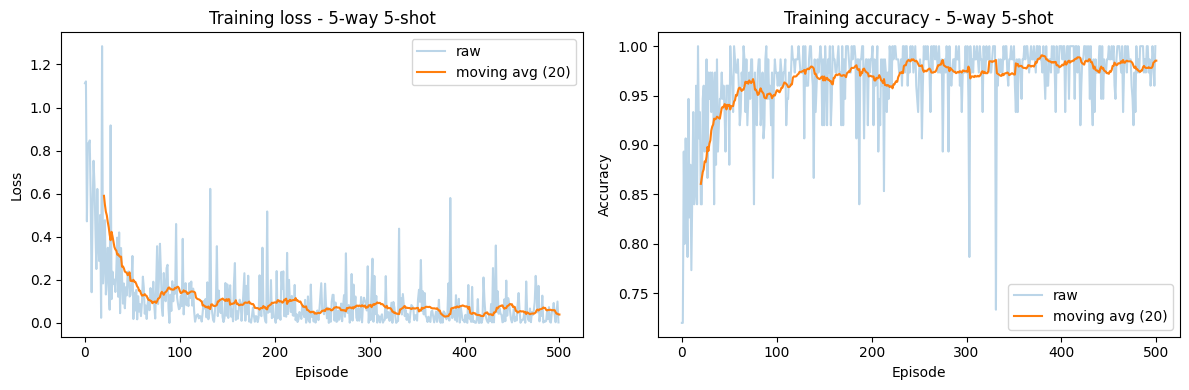

In [31]:
plot_training_curves(losses_5shot, accuracies_5shot, title_suffix="5-way 5-shot")

Again, the loss is decreasing and the accuracy is increasing, so the model is able to learn on the training set.

Evaluation on the test set

In [32]:
mean_acc_5shot, std_acc_5shot, accs_5shot = evaluate_model(
    encoder_5shot, n_way=N_WAY, n_shot=N_SHOT_5, n_query=N_QUERY, num_episodes=NUM_TEST_EPISODES
)

Average accuracy over 100 episodes: 0.9723
Mean +/- 2 std = 0.9723 +/- 0.0507
95% confidence interval (clipped to [0, 1]) = [0.9216, 1.0000]


The model achieved very high accuracy.

### t-SNE visualization of query embeddings and prototypes

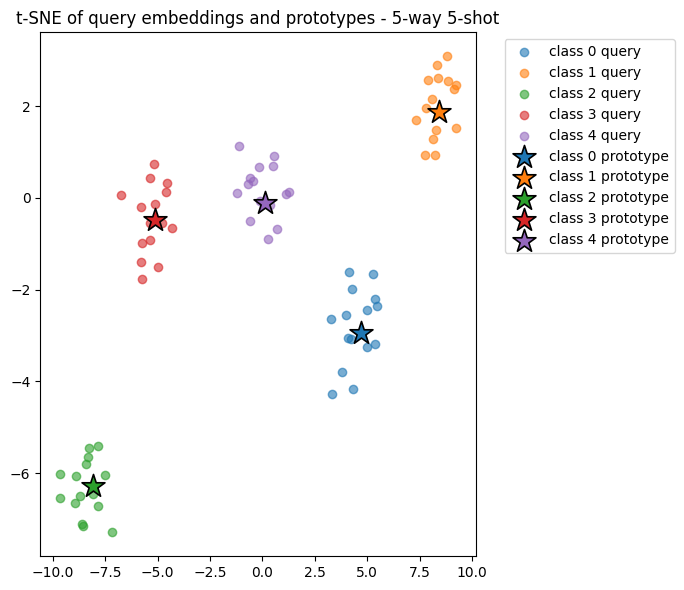

In [33]:
visualize_episode_tsne(encoder_5shot, n_way=N_WAY, n_shot=N_SHOT_5, n_query=N_QUERY, title_suffix="5-way 5-shot")

As before, points within one class are close to each other, the clusters are formed. The stars representing the prototypes are placed close to the corresponding queries.

Below, we compare the test accuracy of the two configurations.

In [34]:
for name, mean_acc, std_acc in [
    ("5-way 1-shot", mean_acc_1shot, std_acc_1shot),
    ("5-way 5-shot", mean_acc_5shot, std_acc_5shot),
]:
    ci_lower = max(0.0, mean_acc - 2 * std_acc)
    ci_upper = min(1.0, mean_acc + 2 * std_acc)
    print(f"{name} accuracy: {mean_acc:.4f}, 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

5-way 1-shot accuracy: 0.8876, 95% CI: [0.7344, 1.0000]
5-way 5-shot accuracy: 0.9723, 95% CI: [0.9216, 1.0000]


Our conclusion is that increasing the number of shots from 1 to 5 gives the prototypes more support instances to average over, which produces more reliable class prototypes and higher accuracy.

The accuracy numbers and t-SNE plots above summarize the model's behavior over many episodes, but it is also useful to look at a handful of individual predictions. Below we take one test episode for the 5-way 1-shot model, show the single support image that defines each class prototype, and then show two query images per class together with the model's prediction. The border is green for a correct prediction and red for an incorrect one.

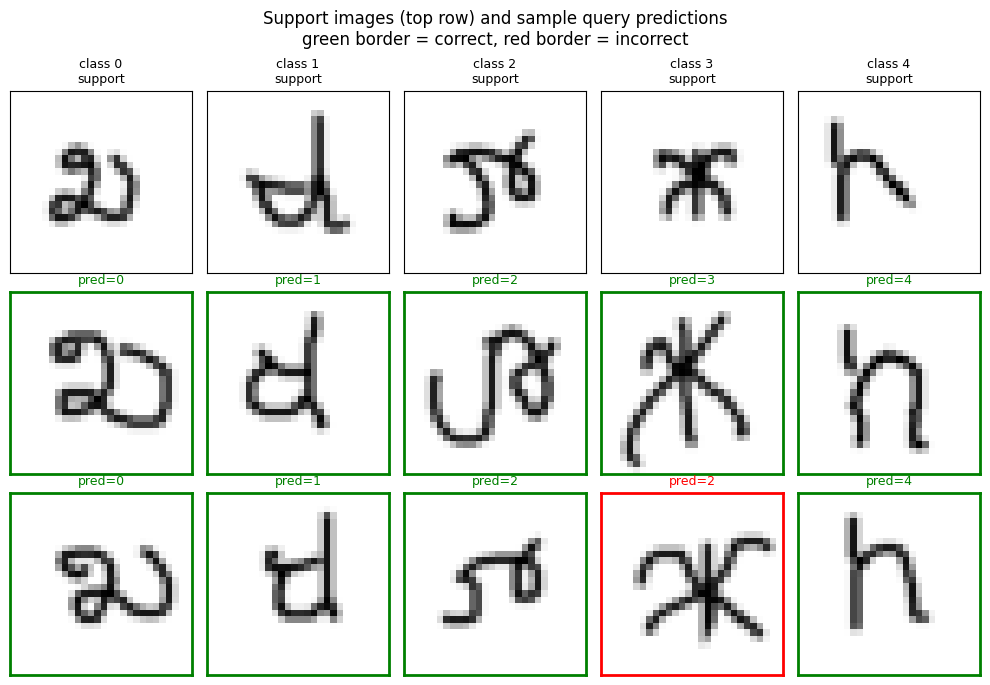

In [35]:
def visualize_episode_predictions(encoder, n_way, n_shot, n_query, n_per_class=2):
    encoder.eval()
    support_images, query_images, query_labels = sample_episode(
        test_dataset, test_class_dict, n_way, n_shot, n_query
    )

    with torch.no_grad():
        support_embeddings = encoder(support_images.to(device))
        query_embeddings = encoder(query_images.to(device))
        prototypes = support_embeddings.view(n_way, n_shot, -1).mean(dim=1)
        distances = torch.cdist(query_embeddings, prototypes) ** 2
        predictions = (-distances).argmax(dim=1).cpu()

    fig, axes = plt.subplots(1 + n_per_class, n_way, figsize=(10, 7))

    for cls in range(n_way):
        axes[0, cls].imshow(support_images[cls].squeeze(), cmap="gray")
        axes[0, cls].set_title(f"class {cls}\nsupport", fontsize=9)
        axes[0, cls].set_xticks([])
        axes[0, cls].set_yticks([])

    for cls in range(n_way):
        class_query_indices = [i for i, label in enumerate(query_labels.tolist()) if label == cls]
        chosen = random.sample(class_query_indices, n_per_class)
        for row, q_idx in enumerate(chosen):
            ax = axes[1 + row, cls]
            ax.imshow(query_images[q_idx].squeeze(), cmap="gray")
            true_label = query_labels[q_idx].item()
            pred_label = predictions[q_idx].item()
            color = "green" if pred_label == true_label else "red"
            ax.set_title(f"pred={pred_label}", fontsize=9, color=color)
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle("Support images (top row) and sample query predictions\ngreen border = correct, red border = incorrect")
    plt.tight_layout()
    plt.show()


random.seed(random_state + 1)
visualize_episode_predictions(encoder_1shot, n_way=N_WAY, n_shot=N_SHOT_1, n_query=N_QUERY)

Even with a single support example per class, the model gets most of the query instances right, consistent with the average accuracy reported above. With multiple different runs, sometimes we observed the mistakes where the characters from class 3 were assigned to class 2. It shows that even though the precision is high, the model can still make mistakes, and not always they are the result of bad handwriting. For human eye, the misclassified examples can still be clearly recognizable, but the euclidean distance based model assignes them wrongly.